In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import plotly.express as px


In [4]:
df = pd.read_csv('1730285881-Airbnb_Open_Data.csv')

C:\Users\hp\AppData\Local\Temp\ipykernel_25812\253668019.py:1: DtypeWarning: Columns (25) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('1730285881-Airbnb_Open_Data.csv')


In [5]:
print(df.head())

        id                                              NAME      host id  \
0  1001254                Clean & quiet apt home by the park  80014485718   
1  1002102                             Skylit Midtown Castle  52335172823   
2  1002403               THE VILLAGE OF HARLEM....NEW YORK !  78829239556   
3  1002755                                               NaN  85098326012   
4  1003689  Entire Apt: Spacious Studio/Loft by central park  92037596077   

  host_identity_verified host name neighbourhood group neighbourhood  \
0            unconfirmed  Madaline            Brooklyn    Kensington   
1               verified     Jenna           Manhattan       Midtown   
2                    NaN     Elise           Manhattan        Harlem   
3            unconfirmed     Garry            Brooklyn  Clinton Hill   
4               verified    Lyndon           Manhattan   East Harlem   

        lat      long        country  ... service fee minimum nights  \
0  40.64749 -73.97237  United St

In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 26 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102058 non-null  int64  
 1   NAME                            101808 non-null  object 
 2   host id                         102058 non-null  int64  
 3   host_identity_verified          101769 non-null  object 
 4   host name                       101654 non-null  object 
 5   neighbourhood group             102029 non-null  object 
 6   neighbourhood                   102042 non-null  object 
 7   lat                             102050 non-null  float64
 8   long                            102050 non-null  float64
 9   country                         101526 non-null  object 
 10  country code                    101927 non-null  object 
 11  instant_bookable                101953 non-null  object 
 12  cancellation_policy  

In [7]:
df.duplicated().value_counts()

False    102058
True        541
Name: count, dtype: int64

In [8]:
print(df[df.duplicated()])

              id                                              NAME  \
102058  35506831    Master Bedroom with private Bathroom & Balcony   
102059  35507383                Cozy 2 br in sunny Fort Greene apt   
102060  35507935               Duplex w/ Terrace @ Box House Hotel   
102061  35508488      Cozy, clean Greenpoint room with yard access   
102062  35509040  2BR XL Loft: Cleaning CDC guidelines implemented   
...          ...                                               ...   
102594   6092437                        Spare room in Williamsburg   
102595   6092990                     Best Location near Columbia U   
102596   6093542                    Comfy, bright room in Brooklyn   
102597   6094094                  Big Studio-One Stop from Midtown   
102598   6094647                              585 sf Luxury Studio   

            host id host_identity_verified            host name  \
102058  55110690425            unconfirmed               UZeyir   
102059  80193772189      

In [10]:
df = df.drop_duplicates()

In [11]:
df.duplicated().value_counts()

False    102058
Name: count, dtype: int64

In [ ]:
df.drop(['house_rules', 'license'], axis=1, inplace=True)
# this two object have insufficent entries

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              102058 non-null  int64  
 1   NAME                            101808 non-null  object 
 2   host id                         102058 non-null  int64  
 3   host_identity_verified          101769 non-null  object 
 4   host name                       101654 non-null  object 
 5   neighbourhood group             102029 non-null  object 
 6   neighbourhood                   102042 non-null  object 
 7   lat                             102050 non-null  float64
 8   long                            102050 non-null  float64
 9   country                         101526 non-null  object 
 10  country code                    101927 non-null  object 
 11  instant_bookable                101953 non-null  object 
 12  cancellation_policy  

In [19]:
 # removing dollar signs in price and service fee
df['price'] = df['price'].str.replace('$','', regex=False)
df['service fee'] = df['service fee'].str.replace('$','', regex=False)

In [20]:
#removing comas in price and service fee
df['price'] = df['price'].str.replace(',','', regex=False)
df['service fee'] = df['service fee'].str.replace(',','', regex=False)

In [23]:
df.rename(columns={'price':'price_$',
                   'service fee': 'service_fee_$'}, inplace=True)

In [29]:
#change the data type to correct one
df['price_$'] = df['price_$'].astype(float)
df['service_fee_$'] = df['service_fee_$'].astype(float)
df['id'] = df['id'].astype(str)
df['host id'] = df['host id'].astype(str)
df['last review'] = pd.to_datetime(df['last review'])
df['Construction year'] = df['Construction year'].astype(float)

In [30]:
df.info()


<class 'pandas.core.frame.DataFrame'>
Index: 102058 entries, 0 to 102057
Data columns (total 24 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102058 non-null  object        
 1   NAME                            101808 non-null  object        
 2   host id                         102058 non-null  object        
 3   host_identity_verified          101769 non-null  object        
 4   host name                       101654 non-null  object        
 5   neighbourhood group             102029 non-null  object        
 6   neighbourhood                   102042 non-null  object        
 7   lat                             102050 non-null  float64       
 8   long                            102050 non-null  float64       
 9   country                         101526 non-null  object        
 10  country code                    101927 non-null  object      

In [32]:
df.loc[df['neighbourhood group'] == 'brookln', 'neighbourhood group'] = 'Brooklyn'

In [33]:
Q1 = df['price_$'].quantile(0.25)
Q3 = df['price_$'].quantile(0.75)
IQR = Q3 - Q1

outliers = df[(df['price_$'] < (Q1 - 1.5 * IQR)) | (df['price_$'] > (Q3 + 1.5 * IQR))]
print(outliers)

Empty DataFrame
Columns: [id, NAME, host id, host_identity_verified, host name, neighbourhood group, neighbourhood, lat, long, country, country code, instant_bookable, cancellation_policy, room type, Construction year, price_$, service_fee_$, minimum nights, number of reviews, last review, reviews per month, review rate number, calculated host listings count, availability 365]
Index: []

[0 rows x 24 columns]


In [ ]:
!pip install scipy


   ---------------------------------------- 0.0/38.6 MB ? eta -:--:--
   -- ------------------------------------- 2.9/38.6 MB 14.0 MB/s eta 0:00:03
   ----- ---------------------------------- 5.8/38.6 MB 14.1 MB/s eta 0:00:03
   ------- -------------------------------- 7.6/38.6 MB 12.4 MB/s eta 0:00:03
   -------- ------------------------------- 8.7/38.6 MB 10.7 MB/s eta 0:00:03
   ---------- ----------------------------- 10.0/38.6 MB 9.7 MB/s eta 0:00:03
   ----------- ---------------------------- 11.3/38.6 MB 9.2 MB/s eta 0:00:03
   ------------- -------------------------- 12.6/38.6 MB 8.8 MB/s eta 0:00:03
   -------------- ------------------------- 14.2/38.6 MB 8.5 MB/s eta 0:00:03
   ---------------- ----------------------- 15.5/38.6 MB 8.4 MB/s eta 0:00:03
   ----------------- ---------------------- 17.3/38.6 MB 8.3 MB/s eta 0:00:03
   ------------------- -------------------- 19.1/38.6 MB 8.4 MB/s eta 0:00:03
   --------------------- ------------------ 20.7/38.6 MB 8.4 MB/s eta 0:

In [38]:
from scipy.stats import zscore

df['price_zscore'] = zscore(df['price_$'])
outliers = df[(df['price_zscore'] > 3) | (df['price_zscore'] < -3)]
print(outliers)

Empty DataFrame
Columns: [id, NAME, host id, host_identity_verified, host name, neighbourhood group, neighbourhood, lat, long, country, country code, instant_bookable, cancellation_policy, room type, Construction year, price_$, service_fee_$, minimum nights, number of reviews, last review, reviews per month, review rate number, calculated host listings count, availability 365, price_zscore]
Index: []

[0 rows x 25 columns]


In [45]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 102057 entries, 0 to 102057
Data columns (total 25 columns):
 #   Column                          Non-Null Count   Dtype         
---  ------                          --------------   -----         
 0   id                              102057 non-null  object        
 1   NAME                            101807 non-null  object        
 2   host id                         102057 non-null  object        
 3   host_identity_verified          101768 non-null  object        
 4   host name                       101653 non-null  object        
 5   neighbourhood group             102028 non-null  object        
 6   neighbourhood                   102041 non-null  object        
 7   lat                             102049 non-null  float64       
 8   long                            102049 non-null  float64       
 9   country                         101525 non-null  object        
 10  country code                    101926 non-null  object      

In [42]:
df.describe()

,lat,long,Construction year,price_$,service_fee_$,minimum nights,number of reviews,last review,reviews per month,review rate number,calculated host listings count,availability 365,price_zscore
count,102049.000000,102049.000000,101843.000000,101810.000000,101784.000000,101657.000000,101874.000000,86225,86239.000000,101738.000000,101738.000000,101609.000000,0.0
mean,40.728097,-73.949652,2012.488124,625.350074,125.038149,8.126691,27.515941,2019-06-11 02:12:21.084372224,1.375387,3.278716,7.937005,141.009192,NaN
min,40.499790,-74.249840,2003.000000,50.000000,10.000000,-1223.000000,0.000000,2012-07-11 00:00:00,0.010000,1.000000,1.000000,-10.000000,NaN
25%,40.688730,-73.982580,2007.000000,340.000000,68.000000,2.000000,1.000000,2018-10-27 00:00:00,0.220000,2.000000,1.000000,3.000000,NaN
50%,40.722290,-73.954440,2012.000000,624.500000,125.000000,3.000000,7.000000,2019-06-13 00:00:00,0.740000,3.000000,1.000000,96.000000,NaN
75%,40.762760,-73.932350,2017.000000,913.000000,183.000000,5.000000,31.000000,2019-07-05 00:00:00,2.010000,4.000000,2.000000,268.000000,NaN
max,40.916970,-73.705220,2022.000000,1200.000000,240.000000,5645.000000,1024.000000,2058-06-16 00:00:00,90.000000,5.000000,332.000000,426.000000,NaN
std,0.055852,0.049502,5.765855,331.669624,66.325303,30.616844,49.567848,NaN,1.748018,1.285084,32.266507,134.974755,NaN


In [44]:
property_types = df['room type'].value_counts().to_frame()
print(property_types)

                 count
room type             
Entire home/apt  53428
Private room     46306
Shared room       2208
Hotel room         115


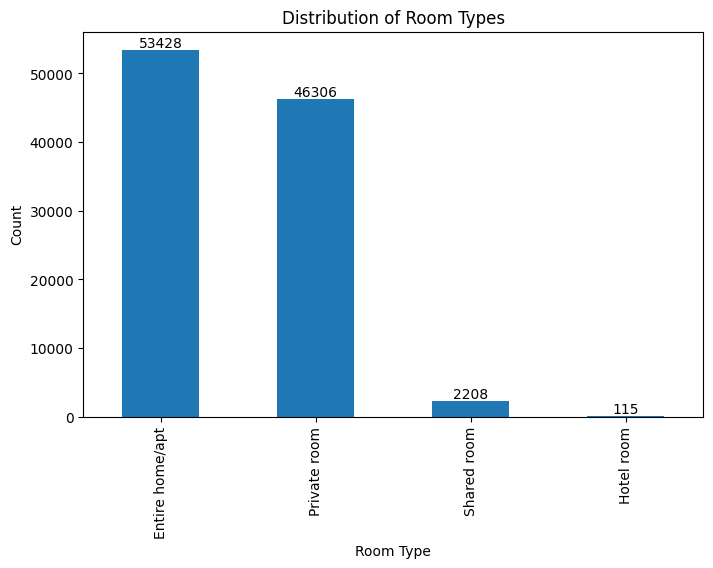

In [ ]:
room_counts = df['room type'].value_counts()
plt.figure(figsize=(8,5))
ax = room_counts.plot(kind='bar')
plt.xlabel('Room Type')
plt.ylabel('Count')
plt.title('Distribution of Room Types')


for i, count in enumerate(room_counts):
    ax.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

In [48]:
hood_group_counts = df['neighbourhood group'].value_counts().to_frame()
print(hood_group_counts)

                     count
neighbourhood group       
Manhattan            43556
Brooklyn             41631
Queens               13197
Bronx                 2694
Staten Island          949
manhatan                 1


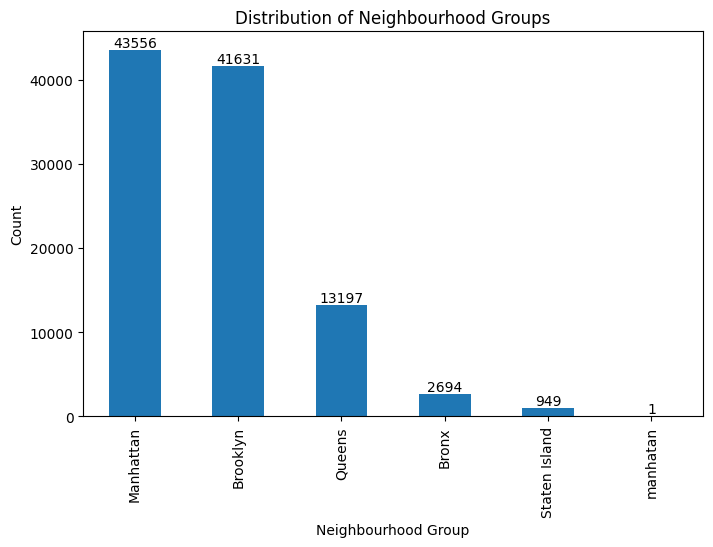

In [ ]:
hood_group_counts = df['neighbourhood group'].value_counts()
plt.figure(figsize=(8,5))
ax = hood_group_counts.plot(kind='bar')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Count')
plt.title('Distribution of Neighbourhood Groups')


for i, count in enumerate(hood_group_counts):
    ax.text(i, count + 2, str(count), ha='center', va='bottom', fontsize=10)

plt.show()

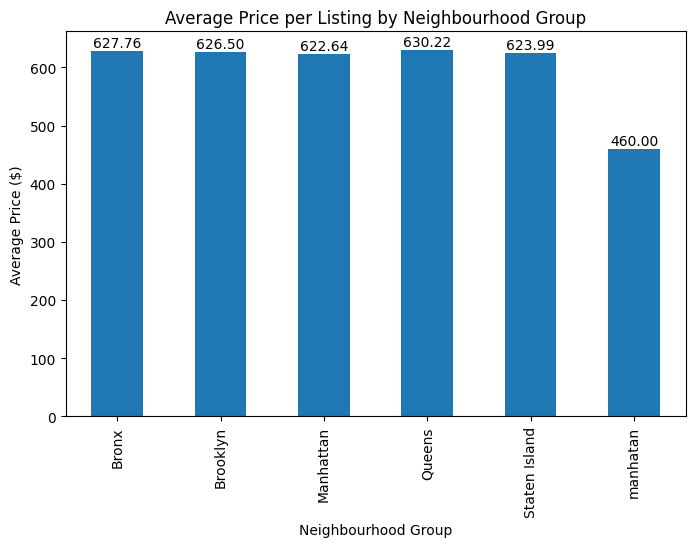

In [ ]:
avg_price_per_group = df.groupby('neighbourhood group')['price_$'].mean()
plt.figure(figsize=(8,5))
ax = avg_price_per_group.plot(kind='bar')
plt.xlabel('Neighbourhood Group')
plt.ylabel('Average Price ($)')
plt.title('Average Price per Listing by Neighbourhood Group')


for i, price in enumerate(avg_price_per_group):
    ax.text(i, price + 2, f'{price:.2f}', ha='center', va='bottom', fontsize=10)

plt.show()

Text(0.5, 1.0, 'Average Price vs Construction Year')

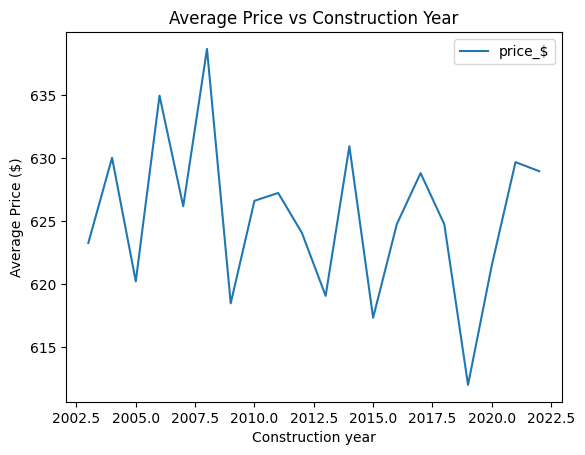

In [58]:
df.groupby(df['Construction year'])['price_$'].mean().to_frame().plot()
plt.xlabel('Construction year')
plt.ylabel('Average Price ($)')
plt.title('Average Price vs Construction Year')


Text(0.5, 1.0, 'Top 10 Hosts by Calculated Host Listings Count')

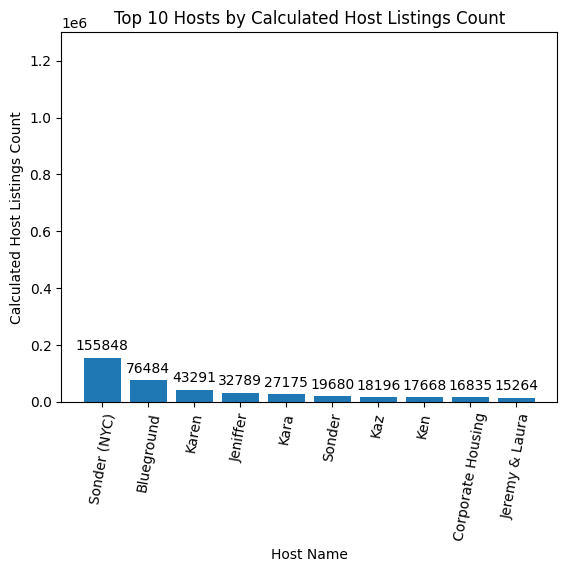

In [ ]:
hosts = df.groupby('host name')['calculated host listings count'].sum().sort_values(ascending = False).nlargest(10).to_frame()
hosts_bar = plt.bar(hosts.index, hosts.loc[:, 'calculated host listings count'])
plt.bar_label(hosts_bar, label = hosts.loc[:, 'calculated host listings count'], padding = 3)
plt.xlabel('Host Name')
plt.ylabel('Calculated Host Listings Count')
plt.xticks(rotation = 80)
plt.ylim([0, 130000])
plt.title('Top 10 Hosts by Calculated Host Listings Count')